# Clean file with modules

In [1]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
parent_dir1 = os.path.abspath(os.path.join(parent_dir, '..'))
sys.path.append(parent_dir1)

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from torch import nn
import torch.nn.functional as F
from simspice.data.SproutDataset import SproutDataset
from torch.utils.data import DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint
import torch
import numpy as np
import matplotlib.pyplot as plt
from cuml.cluster.hdbscan import HDBSCAN

import matplotlib.pyplot as plt
from lightly.loss import NTXentLoss

import simspice.utils.inverse_mapping_functions as imf
import simspice.models.VICReg_Architecture as SA
import wandb
#import umap.umap_ as umap
import tqdm
from datetime import datetime

plt.rcParams['image.origin'] = 'lower'

BATCH_SIZE = 128

In [2]:
simspice = "/d0/tvaresano/SimSPICE/"

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [18]:
dataset_path = simspice+"spectra_Feb2023.nc"

dataset = SproutDataset(dataset_path=dataset_path,
    augmentation_type="single",
    csv_files=simspice + "L2_names.csv",
    log_space=False, normalize_intensity=True,
    sigma_shift=0.1, sigma_gain=0.1, add_noise=True,
    gain_range=(0.1, 4), type_distrib_gain='Gaussian')

dataset_none = SproutDataset(dataset_path=simspice+"spectra_9Jan2023.nc",
    augmentation_type=None, csv_files=simspice + "L2_names.csv",
    log_space=False, normalize_intensity=True,)

dataloader = DataLoader(dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, drop_last=True,
    num_workers=0, pin_memory=torch.cuda.is_available())

In [19]:
id = 'CNN_VICReg_gain0.1-4.0_gauss_distrib_out64'

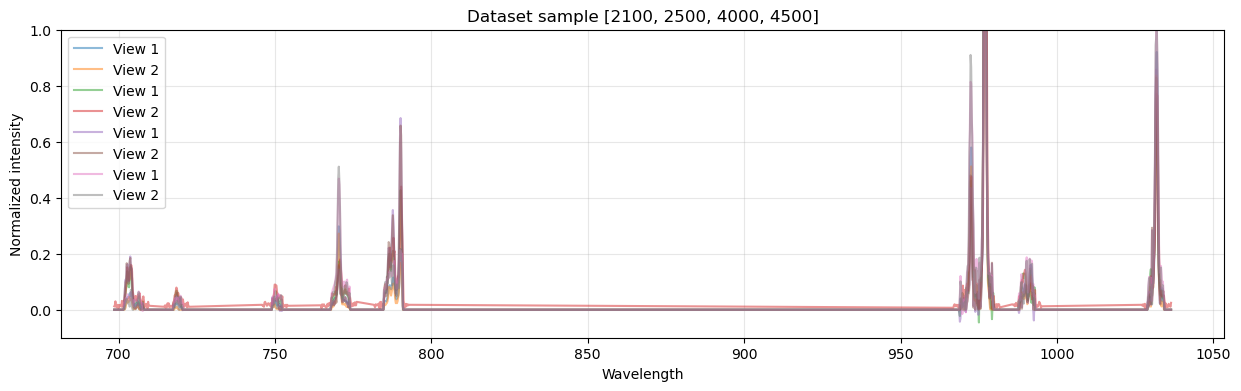

In [20]:
sample_indexs = [2100,2500,4000,4500]

wavelength = dataset.all_spectra.isel(index=sample_indexs[0])["wvl"].values
plt.figure(figsize=(15, 4))
for x in sample_indexs:
    view_1, view_2 = dataset[x]
    view_1 = view_1.squeeze().numpy()
    view_2 = view_2.squeeze().numpy()
    plt.plot(wavelength, view_1, label="View 1", alpha=0.5)
    plt.plot(wavelength, view_2, label="View 2", alpha=0.5)
plt.xlabel("Wavelength")
plt.ylabel("Normalized intensity"), plt.ylim(-.1,1.)
plt.title(f"Dataset sample {sample_indexs}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Train model

In [21]:
epoch_nbr = 5
model = SA.SpectralVICReg(
    backbone_embedding_dim=256,
    projection_hidden_dim=512,
    projection_output_dim=64, # 128 default
    learning_rate=3e-4,
    weight_decay=1e-4,
    maximum_epochs=epoch_nbr,
    invariance_weight=25.0,
    variance_weight=25.0,
    covariance_weight=1.0)

accelerator = "gpu" if torch.cuda.is_available() else "cpu"

wandb_logger = WandbLogger(project="runs_single_augmentation", name=f"{id}_{datetime.today().strftime('%Y-%m-%d')}", log_model=True)

trainer = pl.Trainer(max_epochs=epoch_nbr, devices=1, accelerator=accelerator, logger=wandb_logger)
trainer.fit(model=model, train_dataloaders=dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name            | Type                   | Params | Mode 
-------------------------------------------------------------------
0 | backbone        | SpectralCNNTransformer | 817 K  | train
1 | projection_head | VICRegProjectionHead   | 428 K  | train
2 | criterion       | VICRegLoss             | 0      | train
-------------------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.982     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Epoch 0:   0%|          | 0/907 [00:00<?, ?it/s] 

Epoch 4: 100%|██████████| 907/907 [03:13<00:00,  4.69it/s, v_num=190h, train_loss_step=1.730, train_loss_epoch=1.770]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 907/907 [03:13<00:00,  4.69it/s, v_num=190h, train_loss_step=1.730, train_loss_epoch=1.770]


## If loading from previous checkpoint

In [ ]:
# checkpoint = simspice+"\\notebooks\\FullDataset_64_doubleAug_normalized_spec\\k81c85sl\\checkpoints\\epoch=4-step=9075.ckpt"
# model = SA.SimSiam.load_from_checkpoint(checkpoint)  # Continue epochs

# accelerator = "gpu" if torch.cuda.is_available() else "cpu"
# wandb_logger = WandbLogger(project="FullDataset_64_doubleAug_normalized_spec", log_model=True)
# trainer = pl.Trainer(max_epochs=10, devices=1, accelerator=accelerator, logger=wandb_logger)
# trainer.fit(model=model, train_dataloaders=dataloader)

-------------------------------------------------------------------

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

outputs = []

with torch.no_grad():
    for i in tqdm.tqdm(range(len(dataset_none))):
        spec = dataset_none[i].unsqueeze(0).to(device)

        embedding = model.encode(spec)

        outputs.append(embedding.squeeze(0).cpu().numpy() )

stacked_outputs = np.stack(outputs, axis=0)
print(stacked_outputs.shape)

100%|██████████| 116160/116160 [05:22<00:00, 360.43it/s]


(116160, 256)


In [86]:
# checkpoint = "C:\\Users\\tania\Documents\CU Boulder\CU Alpine\models_ckpts\single_epoch=4-step=45750.ckpt"
# dataset_none = SproutDataset(dataset_path=dataset_path, augmentation_type=None)
# outputs = SA.run_model(checkpoint, dataset_none)

In [24]:
stacked_outputs = np.stack(outputs).squeeze()
stacked_outputs.shape
np.save(simspice+f'notebooks/jobs/model_outputs/stacked_outputs_single_Jan23_{id}.npy', stacked_outputs)

In [6]:
# id = 'CNN_VICReg_updated'
stacked_outputs = np.load(simspice+f'notebooks/jobs/model_outputs/stacked_outputs_single_Feb23_{id}.npy')

## Reducing dimensionality

In [25]:
from cuml.manifold import UMAP
from sklearn.preprocessing import StandardScaler

In [26]:
# Shape: (number_of_spectra, 256)
X = np.asarray(stacked_outputs, dtype=np.float32)

# Standardize the embedding dimensions
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

umap_cluster = UMAP(
    n_components=45,
    n_neighbors=30,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

X_umap_cluster = umap_cluster.fit_transform(X_scaled)

print(X_umap_cluster.shape)
# Expected: (number_of_spectra, 15)

[2026-07-26 19:58:48.124] [CUML] [info] build_algo set to brute_force_knn because random_state is given
(116160, 45)


In [27]:
from matplotlib.lines import Line2D

In [14]:
def plot_cluster_umap2D(xs,ys,n_neighbors=30):
    umap_display = UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=0.05, metric="cosine", random_state=42)
    X_umap_2d = umap_display.fit_transform(X_scaled)
    fig, axes = plt.subplots(len(xs), len(ys), figsize=(18, 15), sharex=True, sharey=True, constrained_layout=True)

    for row, min_cluster_size in enumerate(xs):
        for col, min_samples in enumerate(ys):
            ax = axes[row, col]

            clusterer = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric="euclidean" )

            # Cluster the higher-dimensional UMAP representation.
            labels = clusterer.fit_predict(X_umap_cluster)

            noise_mask = labels == -1
            cluster_mask = labels >= 0

            n_clusters = len(np.unique(labels[cluster_mask]))
            noise_fraction = noise_mask.mean()

            # Plot noise separately.
            ax.scatter(X_umap_2d[noise_mask, 0], X_umap_2d[noise_mask, 1], s=2, alpha=0.15, c="lightgray", rasterized=True)

            # Plot assigned clusters.
            if cluster_mask.any():
                ax.scatter(X_umap_2d[cluster_mask, 0], X_umap_2d[cluster_mask, 1], c=labels[cluster_mask],
                    s=3, alpha=0.7, cmap="tab20", rasterized=True )

            ax.set_title(f"min_cluster_size = {min_cluster_size}\n" f"min_samples = {min_samples}\n" f"{n_clusters} clusters, {noise_fraction:.1%} noise")

            if row == len(xs) - 1:
                ax.set_xlabel("UMAP 1")

            if col == 0:
                ax.set_ylabel("UMAP 2")

    noise_legend = Line2D([0], [0], marker="o", linestyle="", markerfacecolor="lightgray",  markeredgecolor="none", markersize=6, label="HDBSCAN noise",)
    fig.legend(handles=[noise_legend], loc="upper right")
    fig.suptitle("VICReg backbone embeddings\n" "UMAP visualization with HDBSCAN labels", fontsize=16)
    plt.show()

def cluster_print_noise_fraction(xs, ys, X=X_umap_cluster):
    for min_cluster_size in xs:
        for min_samples in ys:
            clusterer = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric="euclidean" )
            labels = clusterer.fit_predict(X)
            noise_mask = labels == -1
            cluster_mask = labels >= 0

            n_clusters = len(np.unique(labels[cluster_mask]))
            noise_fraction = noise_mask.mean()
            print(f"min_cluster = {min_cluster_size} and min_samples = {min_samples}\nNoise fraction = {noise_fraction} \nNumber of cluster = {n_clusters}\n")

In [28]:
xs = [80,100,150,200,300]
ys = [20,30,40,50,100]
# cluster_print_noise_fraction(xs, ys, X=X_umap_cluster)
# plot_cluster_umap2D(xs,ys,n_neighbors=30)

## Clustering

In [29]:
for x in xs:
    for y in tqdm.tqdm(ys):
        clusterer = HDBSCAN(min_cluster_size=x, min_samples=y, metric='euclidean') # <=> cosine?
        clusterer.fit(X_umap_cluster) #stacked_outputs
        labels = clusterer.labels_
        np.save(simspice+f'notebooks/jobs/clustering_outputs/minclus{x}_minsamp{y}.npy', labels)

100%|██████████| 5/5 [00:13<00:00,  2.69s/it]


Text(0.5, 0.98, 'Feb23_Fulltrained_single32')

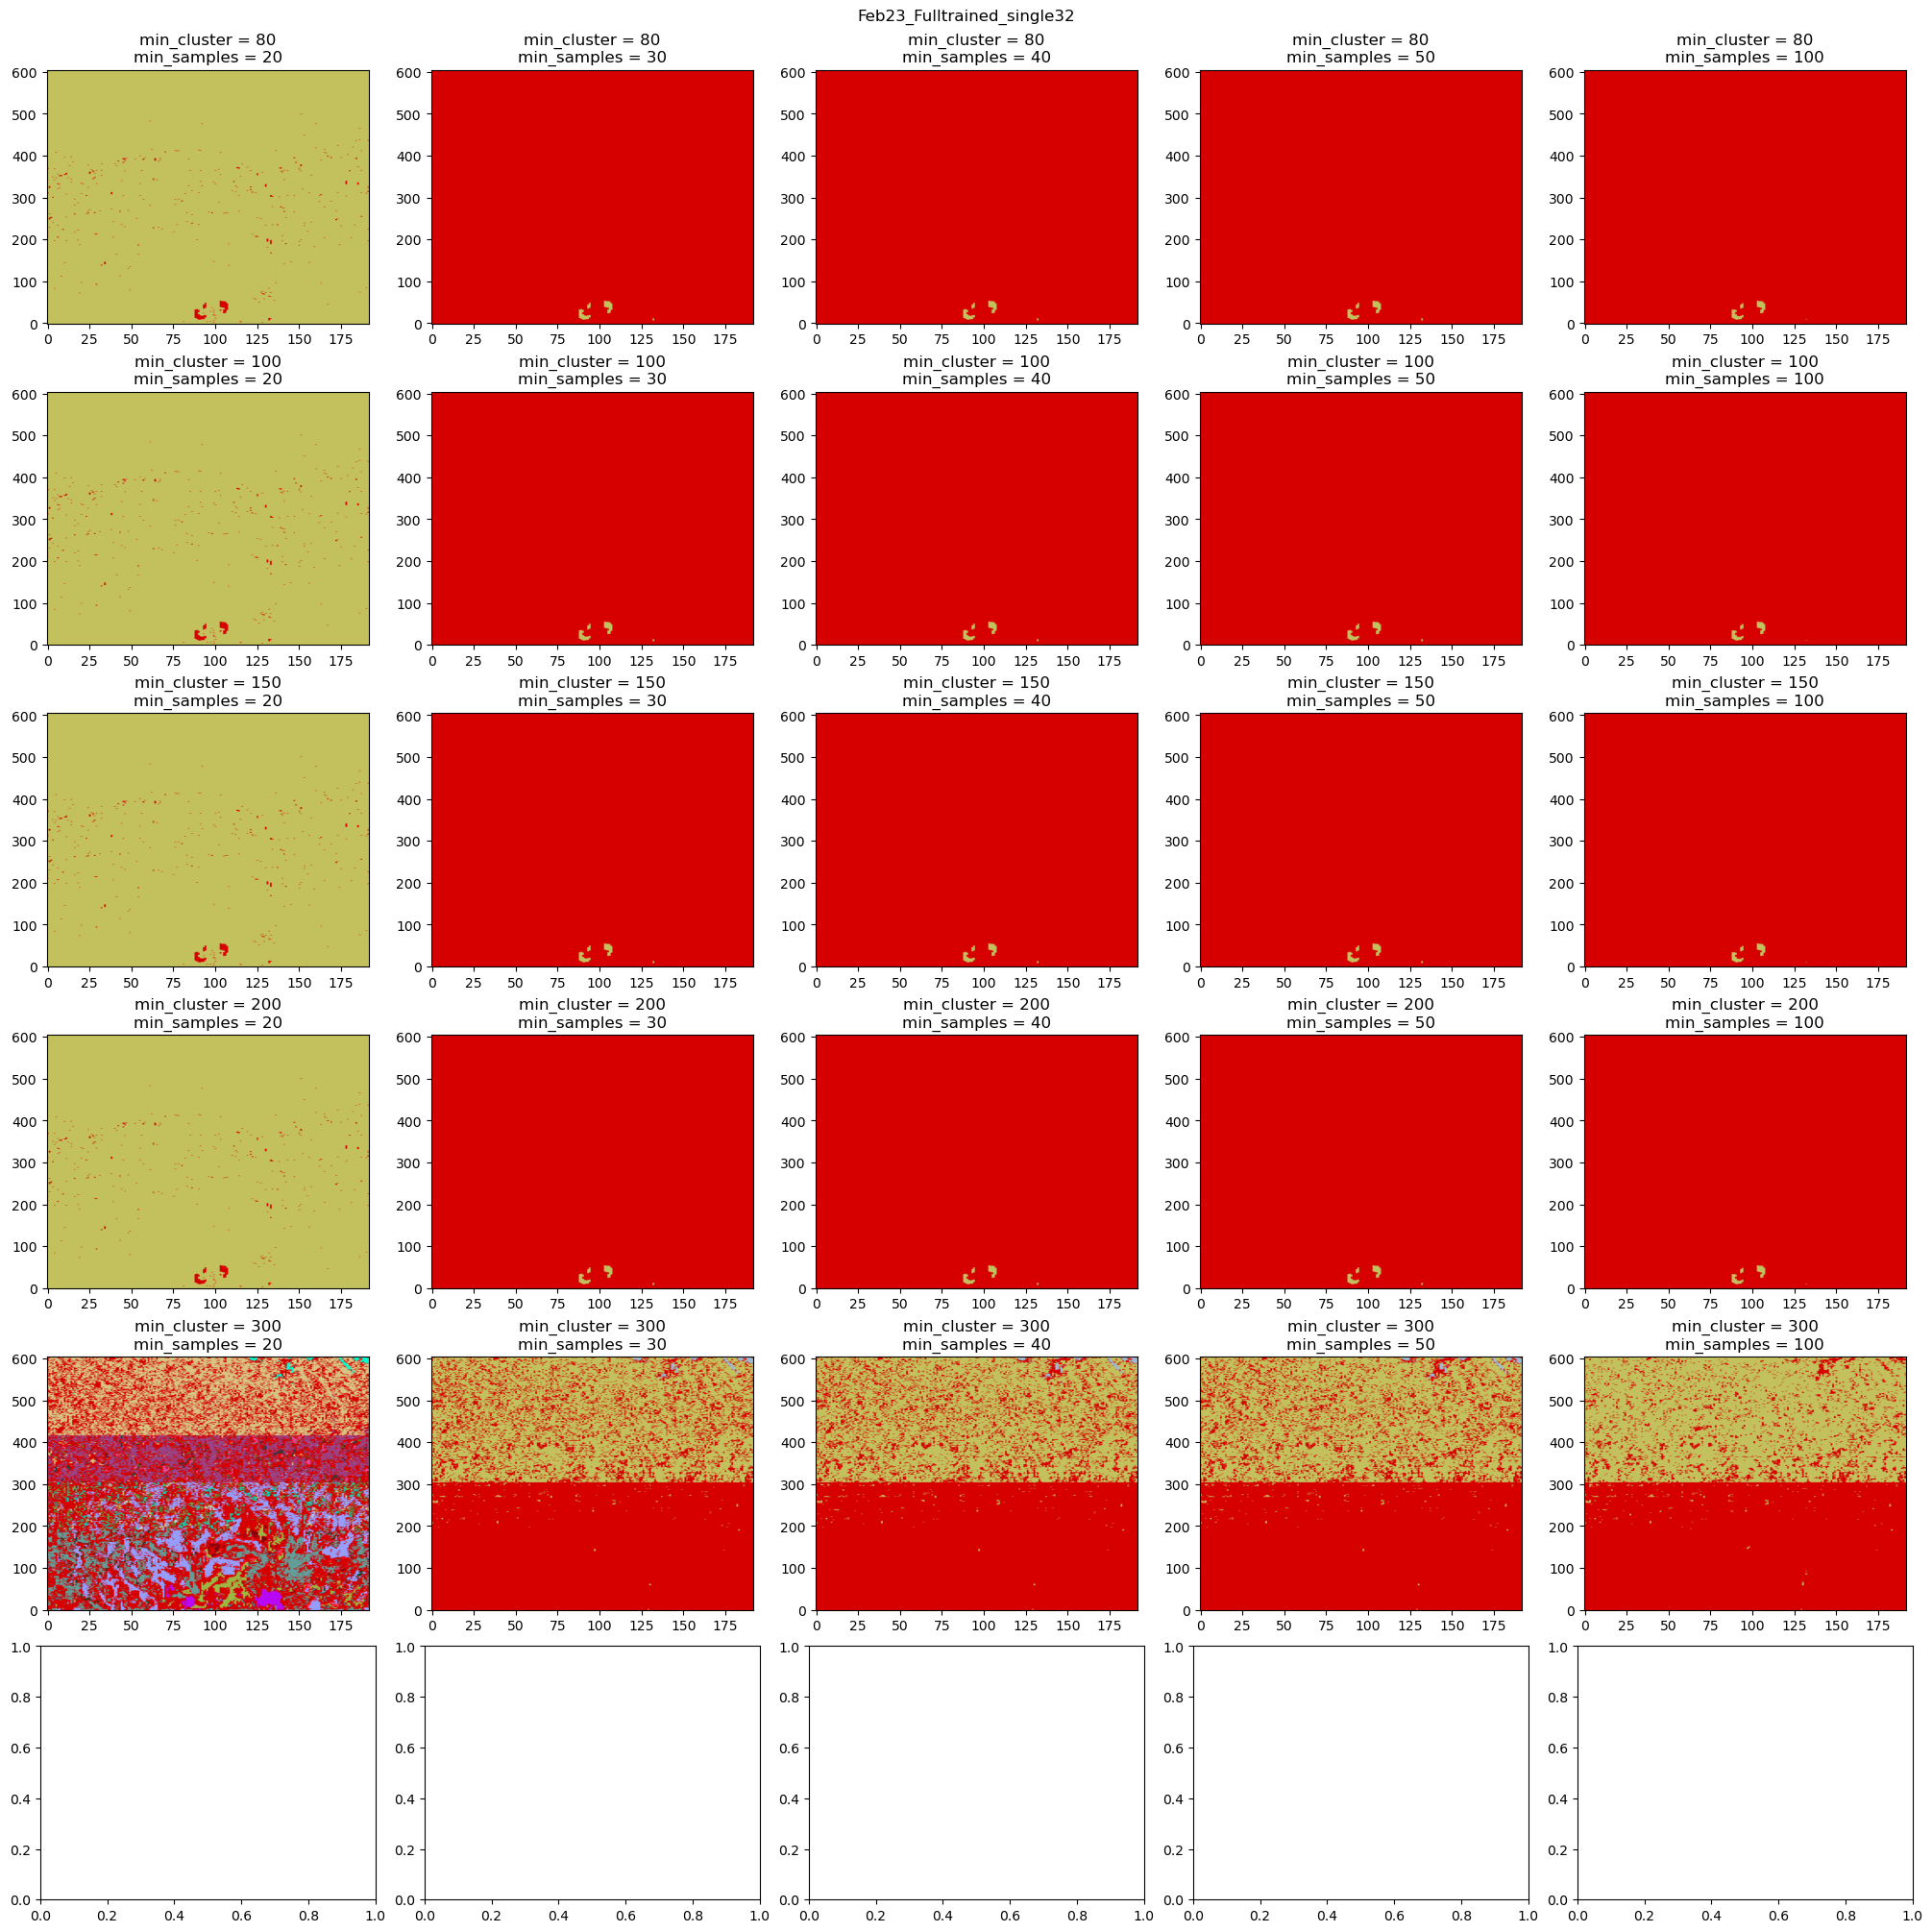

In [31]:
c=0
fig, axes = plt.subplots(6, 5, figsize=(20, 20), constrained_layout=True)
for x in xs:
    for y in ys:
        ax = axes.flat[c]
        c+=1
        labels = np.load(simspice+f'notebooks/jobs/clustering_outputs/minclus{x}_minsamp{y}.npy')
        imf.map_clusters(labels, dataset_path=simspice+'spectra_Feb2023.nc', selected_clusters=None, ax=ax)
        ax.set_title(f"min_cluster = {x}\nmin_samples = {y}")
fig.suptitle('Feb23_Fulltrained_single32')